In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch as mpatches
from scipy.stats import ttest_ind


## Exploration Initiale des Données

In [2]:
# Chargement des donnees de prix d'actions Apple
stock_data = pd.read_csv('Apple Stock Prices (1981 to 2023).csv')
print(stock_data)

# Conversion de la colonne 'Date' en datetime et tri par date
stock_data['Date'] = pd.to_datetime(stock_data['Date'], dayfirst=True)
stock_data.sort_values('Date', inplace=True)
stock_data.set_index('Date', inplace=True)

# Affichage des 5 premieres lignes
print(stock_data.head())

# Type de données
print(stock_data.dtypes)
print()

# Vérification des valeurs nulles
nan_values = stock_data.isnull().sum()
if nan_values.sum() == 0:
    print(' Aucune valeur nulle détectée.')
else:
    print(f' {nan_values.sum()} valeurs nulles trouvées.')

# Vérification des valeurs manquantes
missing_values = stock_data.isna().sum()
print("Valeurs manquantes par colonne :")
print(missing_values)
print()

# Vérification des doublons
duplicates = stock_data.duplicated().sum()
print(f"Nombre de lignes dupliquées : {duplicates}")
print()

             Date        Open        High         Low       Close   Adj Close  \
0      02/01/1981    0.154018    0.155134    0.154018    0.154018    0.119849   
1      05/01/1981    0.151228    0.151228    0.150670    0.150670    0.117244   
2      06/01/1981    0.144531    0.144531    0.143973    0.143973    0.112032   
3      07/01/1981    0.138393    0.138393    0.137835    0.137835    0.107256   
4      08/01/1981    0.135603    0.135603    0.135045    0.135045    0.105085   
...           ...         ...         ...         ...         ...         ...   
10603  23/01/2023  138.119995  143.320007  137.899994  141.110001  141.110001   
10604  24/01/2023  140.309998  143.160004  140.300003  142.529999  142.529999   
10605  25/01/2023  140.889999  142.429993  138.809998  141.860001  141.860001   
10606  26/01/2023  143.169998  144.250000  141.899994  143.960007  143.960007   
10607  27/01/2023  143.160004  147.229996  143.080002  145.929993  145.929993   

         Volume  
0      21

Fréquence d'échantillonnage (en jours) :
Date
1.0    8317
2.0      95
3.0    1927
4.0     265
5.0       2
7.0       1
Name: count, dtype: int64

Moyenne de séances par année : 246.70

 Minimum de séances dans une année : 18 (année 2023)

 Maximum de séances dans une année : 254 (année 1992)


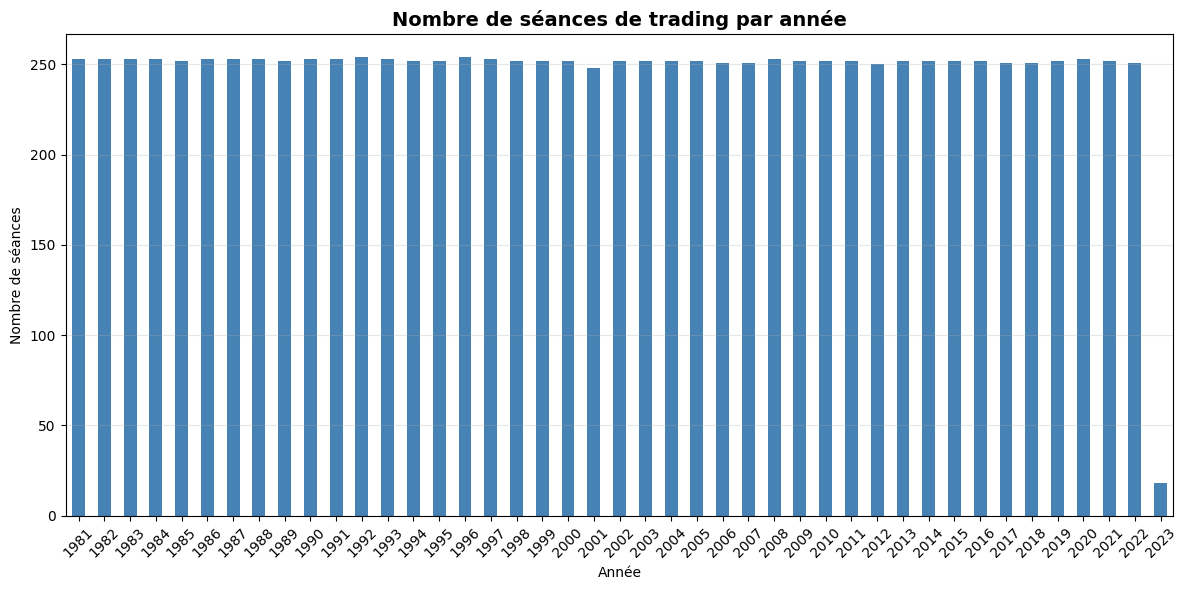

In [3]:
stock_data['Year'] = stock_data.index.year
stock_data['Month'] = stock_data.index.month   
stock_data['Day'] = stock_data.index.day

# Fréquence annuelle des données
freq = stock_data.index.to_series().diff().dt.days.value_counts().sort_index()
print("Fréquence d'échantillonnage (en jours) :")
print(freq)
# annual_counts = stock_data['Year'].value_counts().sort_index()
# print(annual_counts)


# Nombre de séances par année
sessions_per_year = stock_data.groupby('Year').size()
print(f"\nMoyenne de séances par année : {sessions_per_year.mean():.2f}") 
print(f"\n Minimum de séances dans une année : {sessions_per_year.min()} (année {sessions_per_year.idxmin()})")
print(f"\n Maximum de séances dans une année : {sessions_per_year.max()} (année {sessions_per_year.idxmax()})")

sessions_per_year.plot(kind='bar', figsize=(12, 6), color='steelblue')
plt.title('Nombre de séances de trading par année', fontsize=14, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Nombre de séances')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



## Visualisation des données

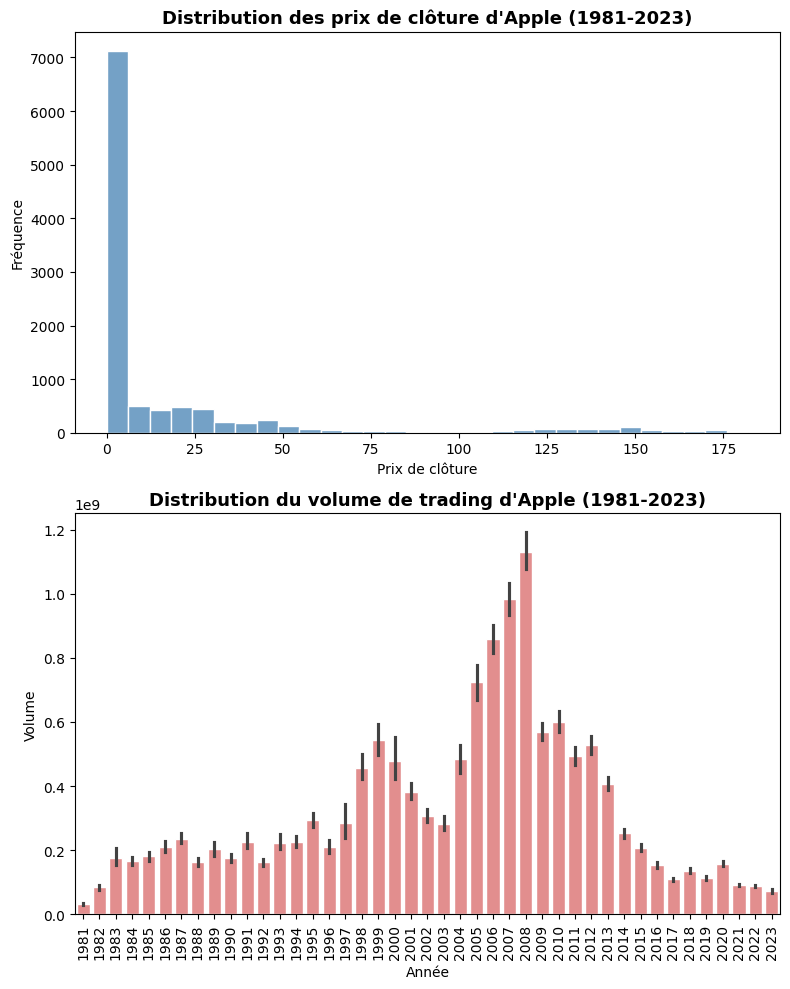

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(8, 10))

# Distribution des prix de clôture
sns.histplot(stock_data['Close'], bins=30, color='steelblue', edgecolor='white', ax=ax[0])
ax[0].set_title("Distribution des prix de clôture d'Apple (1981-2023)", fontsize=13, fontweight='bold')
ax[0].set_xlabel('Prix de clôture')
ax[0].set_ylabel('Fréquence')

# Volume par année
sns.barplot(x=stock_data['Year'], y=stock_data['Volume'], color='lightcoral', edgecolor='white', ax=ax[1])
ax[1].set_title("Distribution du volume de trading d'Apple (1981-2023)", fontsize=13, fontweight='bold')
ax[1].set_xlabel('Année')
ax[1].set_ylabel('Volume')
ax[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

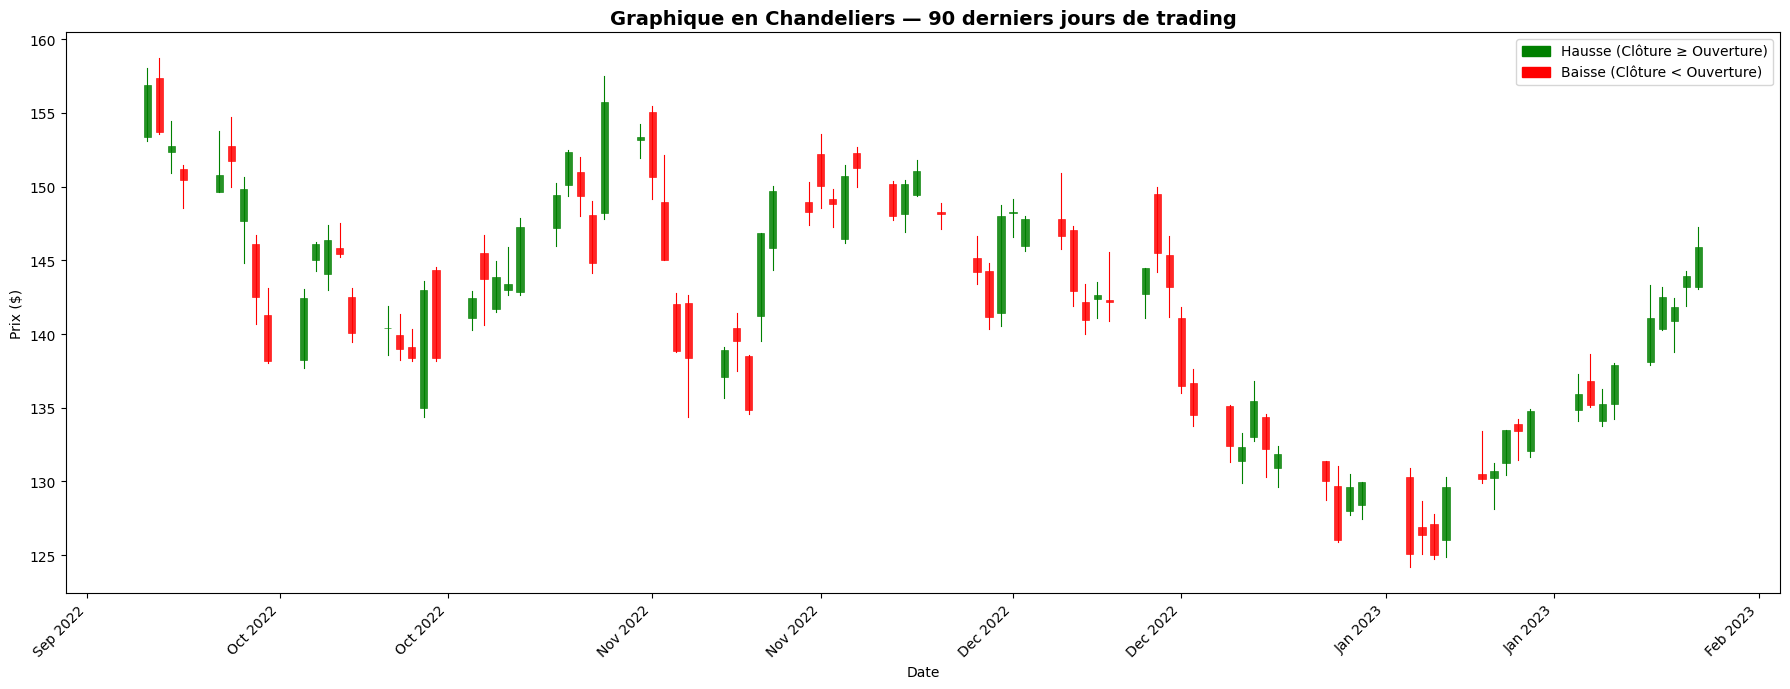

In [5]:
from matplotlib.patches import Patch as mpatches

# Graphique en chandeliers
recent = stock_data.tail(90).copy()

fig, ax = plt.subplots(figsize=(18, 7))
for idx, row in recent.iterrows():
    x = mdates.date2num(idx)
    color = 'green' if row['Close'] >= row['Open'] else 'red'
    row['Date'] = idx
    ax.plot([row['Date'], row['Date']], [row['Low'], row['High']],
            color=color, linewidth=0.8)
    body_bottom = min(row['Open'], row['Close'])
    body_height = abs(row['Close'] - row['Open'])
    rect = Rectangle(
        (mdates.date2num(row['Date']) - 0.3, body_bottom),
        0.6, body_height,
        linewidth=0.5, edgecolor=color, facecolor=color, alpha=0.85
    )
    ax.add_patch(rect)

ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=45)
green_patch = mpatches(color='green', label='Hausse (Clôture ≥ Ouverture)')
red_patch   = mpatches(color='red',   label='Baisse (Clôture < Ouverture)')
ax.legend(handles=[green_patch, red_patch])
ax.set_title('Graphique en Chandeliers — 90 derniers jours de trading', fontsize=14, fontweight='bold')
ax.set_ylabel('Prix ($)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

## 3. Analyse Statistique

In [6]:
# Statistiques descriptives des colonnes clés
cols = ['Open', 'High', 'Low', 'Close', 'Volume']
descriptive_stats = stock_data[cols].describe().T
print("Statistiques descriptives :")
print(descriptive_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])


Statistiques descriptives :
          count          mean           std       min           25%  \
Open    10608.0  1.668917e+01  3.545052e+01  0.049665  2.879460e-01   
High    10608.0  1.687996e+01  3.588285e+01  0.049665  2.968750e-01   
Low     10608.0  1.650082e+01  3.503129e+01  0.049107  2.823547e-01   
Close   10608.0  1.669736e+01  3.547391e+01  0.049107  2.889233e-01   
Volume  10608.0  3.275098e+08  3.378203e+08  0.000000  1.213044e+08   

                 50%           75%           max  
Open    4.888390e-01  1.632089e+01  1.826300e+02  
High    4.955360e-01  1.641848e+01  1.829400e+02  
Low     4.804465e-01  1.615125e+01  1.791200e+02  
Close   4.877010e-01  1.626955e+01  1.820100e+02  
Volume  2.145976e+08  4.066804e+08  7.421641e+09  


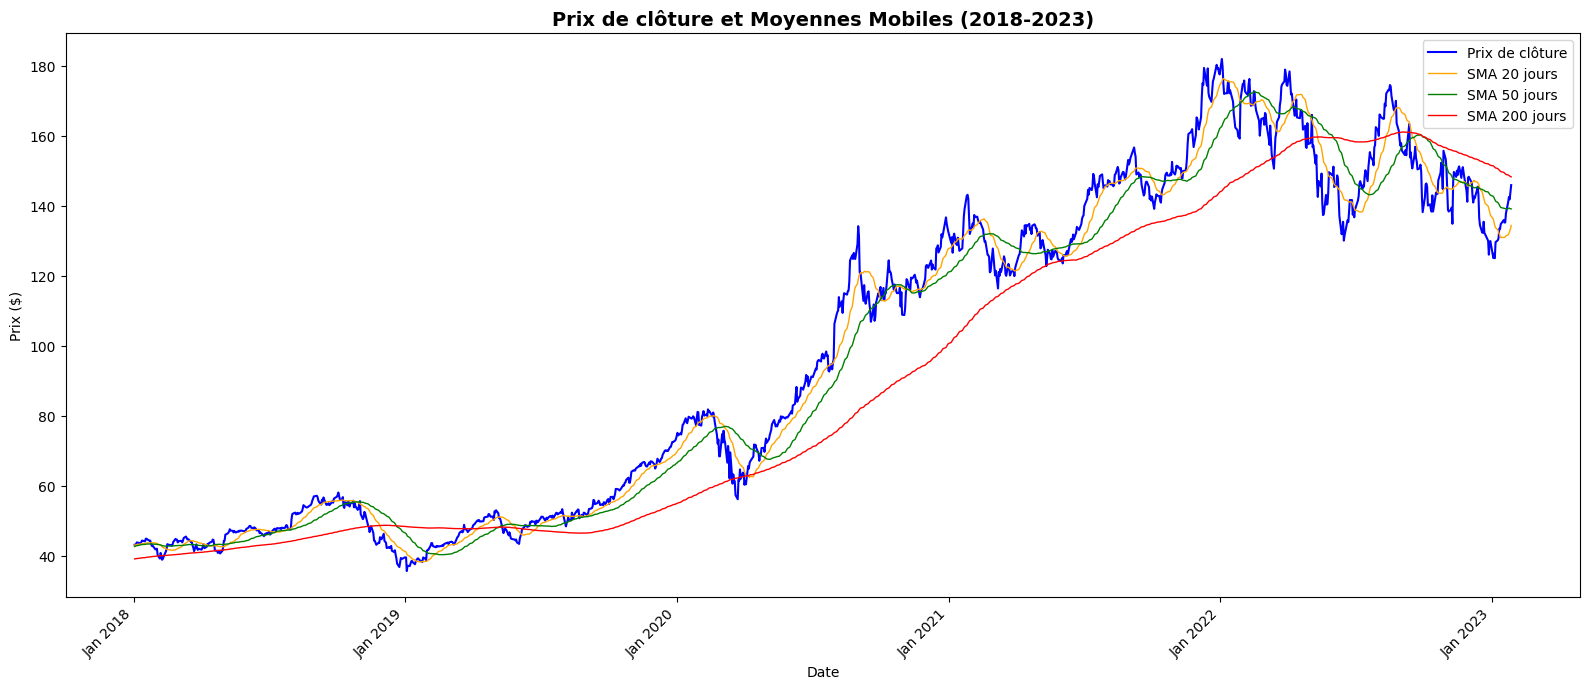

In [7]:
# Moyenne mobile (SMA 20, 50, 200 jours)
stock_data['SMA20'] = stock_data['Close'].rolling(window=20).mean()
stock_data['SMA50'] = stock_data['Close'].rolling(window=50).mean()
stock_data['SMA200'] = stock_data['Close'].rolling(window=200).mean()

# Zoom sur les 5 dernières années
recent_5y = stock_data[stock_data['Year'] >= 2018]

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(recent_5y.index, recent_5y['Close'], label='Prix de clôture', color='blue', linewidth=1.5)
ax.plot(recent_5y.index, recent_5y['SMA20'], label='SMA 20 jours', color='orange', linewidth=1)
ax.plot(recent_5y.index, recent_5y['SMA50'], label='SMA 50 jours', color='green', linewidth=1)
ax.plot(recent_5y.index, recent_5y['SMA200'], label='SMA 200 jours', color='red', linewidth=1)
ax.set_title('Prix de clôture et Moyennes Mobiles (2018-2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Prix ($)')  
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

## 4. Tests d'hypothèses

In [8]:
# Test t : comparaison du cours de clôture moyen entre différentes années
years_a, years_b = 2020, 2021
close_a = stock_data[stock_data['Year'] == years_a]['Close']
close_b = stock_data[stock_data['Year'] == years_b]['Close']

t_stat, p_value = ttest_ind(close_a, close_b, equal_var=False)
print(f"Test t entre {years_a} et {years_b} : t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")
print(f"Moyenne de clôture en {years_a} : {close_a.mean():.2f}")
print(f"Moyenne de clôture en {years_b} : {close_b.mean():.2f}")
if p_value < 0.05 :
    print(f' Résultat significatif (p < 0.05) : la différence de moyenne est statistiquement significative.')
else:
    print(f' Résultat non-significatif (p ≥ 0.05).')

Test t entre 2020 et 2021 : t-statistic = -27.6093, p-value = 0.0000
Moyenne de clôture en 2020 : 95.35
Moyenne de clôture en 2021 : 140.99
 Résultat significatif (p < 0.05) : la différence de moyenne est statistiquement significative.


In [10]:
# Test t sur plusieurs paires d'années
years = list(range(2010, 2023))
results = []
for y in years[:-1]:
    a = stock_data[stock_data['Year'] == y]['Close']
    b = stock_data[stock_data['Year'] == y+1]['Close']
    t, p = ttest_ind(a, b, equal_var=False)
    results.append({'Paire': f'{y} vs {y+1}', 't-stat': round(t, 3), 'p-value': round(p, 5), 'Significatif': '✅' if p < 0.05 else '❌'})

display(pd.DataFrame(results).set_index('Paire'))

,t-stat,p-value,Significatif
Paire,,,
2010 vs 2011,-36.234,0.0,✅
2011 vs 2012,-46.707,0.0,✅
2012 vs 2013,20.305,0.0,✅
2013 vs 2014,-26.489,0.0,✅
2014 vs 2015,-28.591,0.0,✅
2015 vs 2016,22.613,0.0,✅
2016 vs 2017,-44.144,0.0,✅
2017 vs 2018,-24.152,0.0,✅
2018 vs 2019,-7.577,0.0,✅


In [11]:
# Rendements quotidiens et test de normalité
stock_data['Daily_Return'] = stock_data['Close'].pct_change() * 100

returns = stock_data['Daily_Return'].dropna()

# Statistiques
print(' Statistiques des rendements quotidiens ')
print(f'Moyenne    : {returns.mean():.4f}%')
print(f'Médiane    : {returns.median():.4f}%')
print(f'Écart-type : {returns.std():.4f}%')

 Statistiques des rendements quotidiens 
Moyenne    : 0.1052%
Médiane    : 0.0000%
Écart-type : 2.8235%


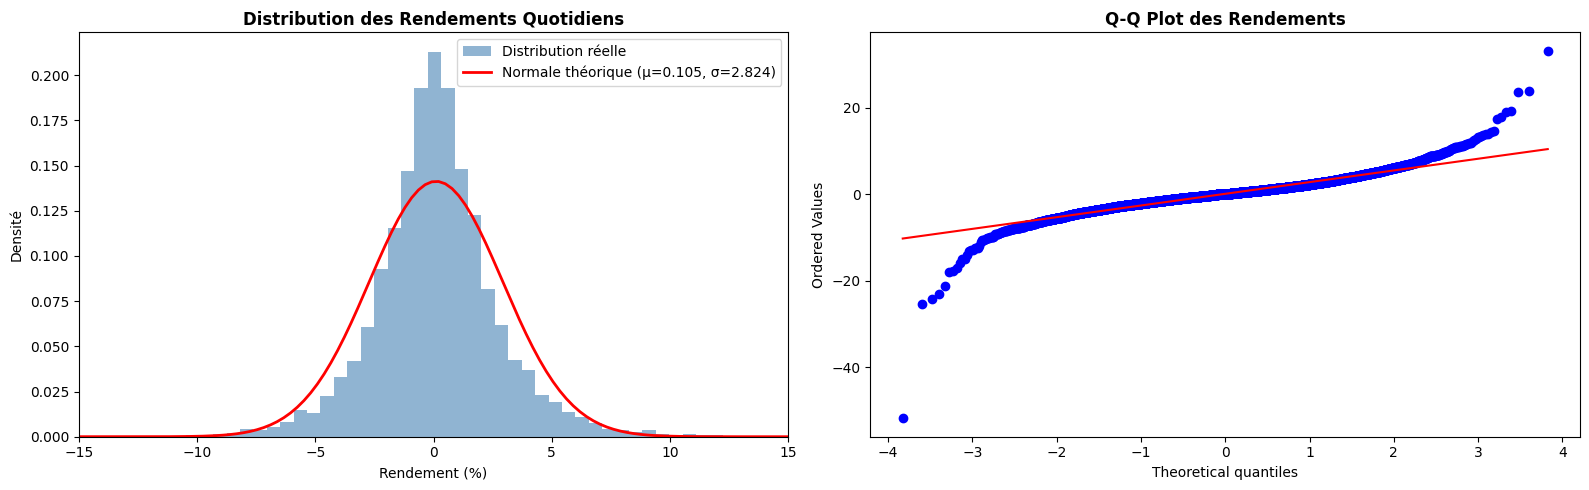

In [20]:
from scipy import stats

# Visualisation de la distribution des rendements
fig, axes = plt.subplots(1, 2, figsize =(16, 5))

# Histogramme + courbe normale théorique
x = np.linspace(returns.min(), returns.max(), 300)
mu, sigma = returns.mean(), returns.std()
normal_pdf = stats.norm.pdf(x, mu, sigma)

axes[0].hist(returns, bins=150, density=True, alpha=0.6, color='steelblue', label='Distribution réelle')
axes[0].plot(x, normal_pdf, 'r-', linewidth=2, label=f'Normale théorique (μ={mu:.3f}, σ={sigma:.3f})')
axes[0].set_xlim(-15, 15)
axes[0].set_title('Distribution des Rendements Quotidiens', fontweight='bold')
axes[0].set_xlabel('Rendement (%)')
axes[0].set_ylabel('Densité')
axes[0].legend()

# QQ-plot
stats.probplot(returns, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot des Rendements', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Techniques Statistiques Avancées (Bonus NumPy)

In [15]:
# --- np.convolve pour les moyennes mobiles ---
close_arr = stock_data['Close'].values

def sma_convolve(series, window):
    """Moyenne mobile via np.convolve (noyau uniforme)."""
    kernel = np.ones(window) / window
    sma = np.convolve(series, kernel, mode='valid')
    # Réaligner avec l'index d'origine
    pad = np.full(window - 1, np.nan)
    return np.concatenate([pad, sma])

sma20_np  = sma_convolve(close_arr, 20)
sma50_np  = sma_convolve(close_arr, 50)
sma200_np = sma_convolve(close_arr, 200)

# Vérification de cohérence avec pandas
stock_data['SMA_20'] = stock_data['SMA20']
stock_data['SMA_50'] = stock_data['SMA50']
stock_data['SMA_200'] = stock_data['SMA200']

diff = np.nanmax(np.abs(sma20_np - stock_data['SMA_20'].values))
print(f'Différence max SMA-20 (np vs pandas) : {diff:.2e}  ✅' if diff < 1e-9 else f'Différence : {diff}')
print('Moyennes mobiles calculées avec np.convolve.')

Différence max SMA-20 (np vs pandas) : 5.68e-14  ✅
Moyennes mobiles calculées avec np.convolve.


=== Matrice de corrélation (np.corrcoef) ===


,Close,SMA_20,SMA_50,SMA_200,Volume
Close,1.0000,0.9987,0.9967,0.9898,-0.2249
SMA_20,0.9987,1.0000,0.9987,0.9920,-0.2237
SMA_50,0.9967,0.9987,1.0000,0.9949,-0.2231
SMA_200,0.9898,0.9920,0.9949,1.0000,-0.2233
Volume,-0.2249,-0.2237,-0.2231,-0.2233,1.0000


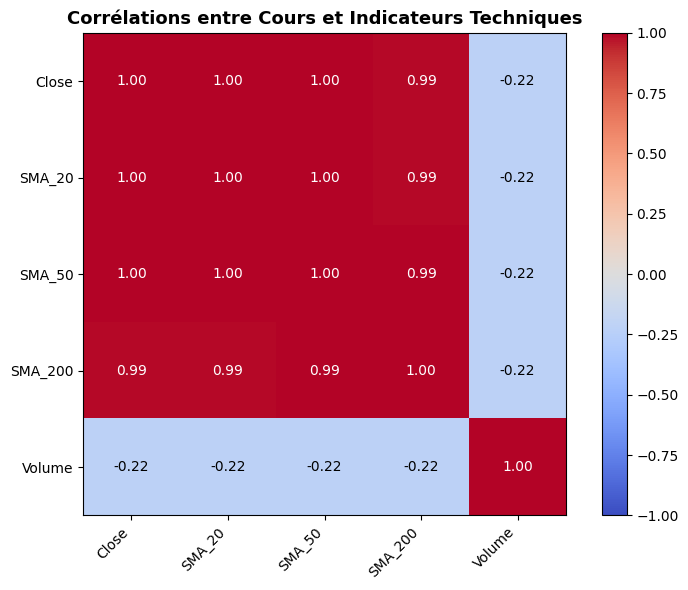

In [16]:
# --- np.corrcoef : corrélations entre indicateurs financiers ---

# Construction du tableau de features
vol_arr = stock_data['Volume'].values

# On supprime les NaN (les 199 premières lignes pour SMA_200)
valid = ~(np.isnan(sma20_np) | np.isnan(sma50_np) | np.isnan(sma200_np))

features = {
    'Close'   : close_arr[valid],
    'SMA_20'  : sma20_np[valid],
    'SMA_50'  : sma50_np[valid],
    'SMA_200' : sma200_np[valid],
    'Volume'  : vol_arr[valid],
}

mat = np.array(list(features.values()))
corr_matrix = np.corrcoef(mat)

labels = list(features.keys())
corr_df = pd.DataFrame(corr_matrix, index=labels, columns=labels)

print('=== Matrice de corrélation (np.corrcoef) ===')
display(corr_df.round(4))

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr_matrix[i,j]:.2f}', ha='center', va='center', fontsize=10,
                color='white' if abs(corr_matrix[i,j]) > 0.6 else 'black')
ax.set_title('Corrélations entre Cours et Indicateurs Techniques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

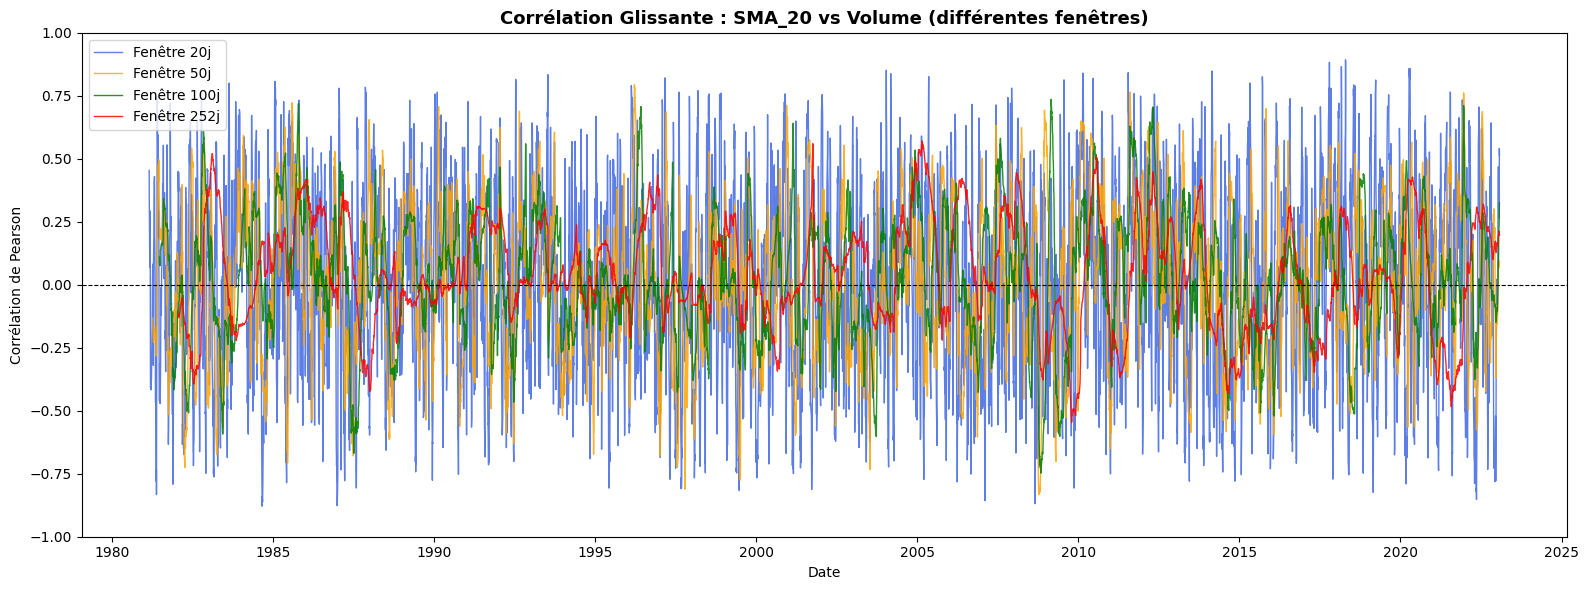

In [18]:
# --- Corrélations glissantes SMA_20 vs Volume sur différentes périodes ---
windows = [20, 50, 100, 252]  # 252 ≈ 1 an de trading

fig, ax = plt.subplots(figsize=(16, 6))
colors = ['royalblue', 'orange', 'green', 'red']

for w, c in zip(windows, colors):
    roll_corr = stock_data['SMA_20'].rolling(w).corr(stock_data['Volume'])
    ax.plot(stock_data.index, roll_corr, label=f'Fenêtre {w}j', color=c, linewidth=1, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Corrélation Glissante : SMA_20 vs Volume (différentes fenêtres)', fontsize=13, fontweight='bold')
ax.set_ylabel('Corrélation de Pearson')
ax.set_xlabel('Date')
ax.legend()
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.show()

In [ ]:
# --- Analyse de la volatilité réalisée (écart-type glissant des rendements) ---
stock_data['Volatility_20']  = stock_data['Daily_Return'].rolling(20).std()
stock_data['Volatility_252'] = stock_data['Daily_Return'].rolling(252).std() * np.sqrt(252)  # Volatilité annualisée

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

axes[0].plot(stock_data['Date'], stock_data['Close'], color='royalblue', linewidth=0.8)
axes[0].set_title('Cours de Clôture', fontweight='bold')
axes[0].set_ylabel('Prix ($)')

axes[1].fill_between(stock_data['Date'], stock_data['Volatility_20'], alpha=0.4, color='orange', label='Volatilité 20j')
axes[1].plot(stock_data['Date'], stock_data['Volatility_252'], color='red', linewidth=1.5, label='Volatilité annualisée (252j)')
axes[1].set_title('Volatilité Réalisée des Rendements', fontweight='bold')
axes[1].set_ylabel('Volatilité (%)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\n Statistiques de la volatilité annualisée ')
vol = stock_data['Volatility_252'].dropna()
print(f'Volatilité annualisée moyenne : {vol.mean():.2f}%')
print(f'Volatilité annualisée max     : {vol.max():.2f}% (vers {stock_data.loc[vol.idxmax(), "Date"].date()})')

In [ ]:
# --- Résumé final : rendement cumulé ---
stock_data['Cumulative_Return'] = (1 + stock_data['Daily_Return'] / 100).cumprod()

total_return = (stock_data['Cumulative_Return'].iloc[-1] - 1) * 100
years_span   = (stock_data['Date'].iloc[-1] - stock_data['Date'].iloc[0]).days / 365.25
cagr         = ((stock_data['Cumulative_Return'].iloc[-1]) ** (1 / years_span) - 1) * 100

fig, ax = plt.subplots(figsize=(16, 6))
ax.semilogy(stock_data['Date'], stock_data['Cumulative_Return'], color='royalblue', linewidth=1)
ax.set_title(f'Rendement Cumulé d\'Apple (échelle log) — Total : +{total_return:,.0f}%  |  CAGR : {cagr:.1f}%/an',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Rendement cumulé (base 1)')
ax.set_xlabel('Date')
ax.fill_between(stock_data['Date'], stock_data['Cumulative_Return'], alpha=0.15, color='royalblue')
plt.tight_layout()
plt.show()

print(f'\nRendement total  : +{total_return:,.0f}%')
print(f'CAGR             : {cagr:.2f}% / an')
print(f'Période          : {years_span:.1f} ans')